In [9]:
library(ggplot2)
library(data.table)
library(forcats)
library(ggrepel)
library(cowplot)

### COGS genes across autoimmune traits in ILC3s vs IL22 CRISPRi screen genes in MNK3 cells

### The enrichment analysis was performed using Mageck. 
### Here plotting results.

In [10]:
### Connect COGS genes to the screen genes, based on gene names. Note, this will not be perfect, because we compare human with mouse.
### get the annotated pm - because some of the genes were not baited, but still included in the results of multiCOGS
### Note only protein coding were added to the pm.

genes <- fread("~/HRJ_monocytes/hILCs/rCOGS_in/Version3_revision2/COGS_input_revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/ILC3_chicago_fres_bin_5kb_abc_023_fres_extended_peakm_13012025_modified.txt_pm.format.txt")

length(unique(genes$ensg)) # 14233

### To connect with the CRISPR screen, we need the name.
pm_genes <- unique(genes[, .(name)])
#pm_genes

### Save to connect to CRISPR data
fwrite_headers(pm_genes, file = "~/HRJ_monocytes/hILCs/rCOGS_in/Version3_revision2/COGS_input_revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/genes_in_ILC3_pm.txt")


### Read in the CRISPR
sg3 <- fread("~/HRJ_monocytes/hILCs/oltz_CRISPR/biorxiv_Brown2025_suppl/geneLevel_analyses_biorxiv_screen_uppercase.txt")
sg3_keep <- sg3[id %in% pm_genes$name]
length(unique(sg3$id)) # 9262
length(unique(sg3_keep$id)) # 6438

fwrite_headers(sg3_keep, file = "~/HRJ_monocytes/hILCs/oltz_CRISPR/biorxiv_Brown2025_suppl/geneLevel_analyses_biorxiv_screen_uppercase_COGS_ILC3_genes.txt")

sg3_keep <- fread("~/HRJ_monocytes/hILCs/oltz_CRISPR/biorxiv_Brown2025_suppl/geneLevel_analyses_biorxiv_screen_uppercase_COGS_ILC3_genes.txt")
#sg3_keep

[1] 14233

[1] 9262

[1] 6438

### Make dotplots with genes highlighted, similarly to the Brown et al. paper.

Warning message:
“Removed 9246 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”
Warning message:
“Removed 9249 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”
Warning message:
“Removed 9246 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”
Warning message:
“Removed 9249 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


pdf 
  2

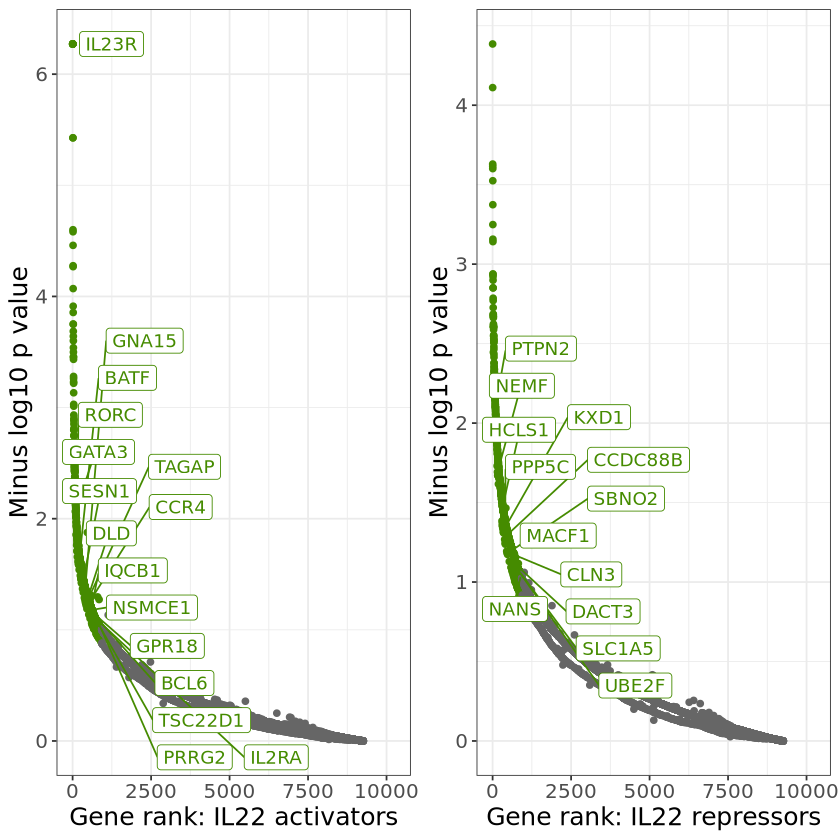

In [11]:
sg3 <- fread("~/HRJ_monocytes/hILCs/oltz_CRISPR/biorxiv_Brown2025_suppl/geneLevel_analyses_biorxiv_screen_uppercase.txt")

# Plot for the genes that were identified in any of the 6 autoimmune traits.
allTraits <- fread("~/HRJ_monocytes/hILCs/COGS_results/cross_trait/prioritised_genes_multiCOGS_table.txt")
allTraits_ILC3 <- allTraits[PSC_ILC3 == "+" | Celiac_ILC3 == "+" | IBD_ILC3 == "+" | UC_ILC3 == "+" | 
                           CD_ILC3 == "+" | Asthma_ILC3 == "+", .(`Gene Name`)]
#allTraits_ILC3

sg3[, COGS_gene := id %in% allTraits_ILC3$`Gene Name`]

### NEG - IL22 Activators
sg3_neg <- sg3[, c(1:8,16)]
setorder(sg3_neg, `neg|rank`)
# Set label for only the COGs genes in top 10% ranking CRISPRi genes
sg3_neg[COGS_gene == T & `neg|rank` <= (nrow(sg3)/10), Gene := id]
sg3_neg[, top_10percent := `neg|rank` <= (nrow(sg3)/10)]
#sg3_neg
### IL22 activators (i.e. neg ranking)

p <- ggplot(sg3_neg, aes(x = `neg|rank`, y = -log10(`neg|p-value`), label = Gene, color = top_10percent))
activators <- p + geom_point() + geom_label_repel(nudge_x = 1000, force_pull = 0, 
                                  max.overlaps = 1000) + 
theme_bw() + theme(legend.position="none") +
scale_color_manual(values=c("gray40", "chartreuse4")) + 
labs(color = "Gene in top 10%") + 
ylab("Minus log10 p value") + 
xlab("Gene rank: IL22 activators") + 
theme(text = element_text(size = 15))
#length(unique(sg3_neg$id))
#nrow(sg3_neg)
#sg3_neg

### POS - IL22 repressors
sg3_pos <- sg3[, c(1, 10:16)]
#sg3_pos
setorder(sg3_pos, `pos|rank`)
# Set label for only the COGs genes in top 10% ranking CRISPRi genes
sg3_pos[COGS_gene == T & `pos|rank` <= (nrow(sg3)/10), Gene := id]
sg3_pos[, top_10percent := `pos|rank` <= (nrow(sg3)/10)]

### IL22 repressors (i.e. pos ranking)
q <- ggplot(sg3_pos, aes(x = `pos|rank`, y = -log10(`pos|p-value`), label = Gene, color = top_10percent))
repressors <- q + geom_point() + geom_label_repel(nudge_x = 1000, force_pull = 0, 
                                  max.overlaps = 1000) + 
theme_bw() + theme(legend.position="none") +
scale_color_manual(values=c("gray40", "chartreuse4")) + 
labs(color = "Gene in top 10%") + 
ylab("Minus log10 p value") + 
xlab("Gene rank: IL22 repressors") + 
theme(text = element_text(size = 15))

library(cowplot)
plot_grid(activators, repressors)
svg(file = "./CRISPRi_activators_repressors_COGS_screen3.svg", width = 8, height = 5.5)
plot_grid(activators, repressors)
dev.off()



id,num,neg|score,neg|p-value,neg|fdr,neg|rank,neg|goodsgrna,neg|lfc,COGS_gene,Gene,top_10percent,sigScreen_COGS,Sig_Gene
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<lgl>,<chr>,<lgl>,<lgl>,<chr>
IL23R,5,4.6000e-12,5.3500e-07,0.000550,2,5,-2.15250,TRUE,IL23R,TRUE,TRUE,IL23R
GATA3,10,1.2902e-03,8.6016e-03,0.744564,86,6,-0.82667,TRUE,GATA3,TRUE,TRUE,GATA3
RORC,10,3.3448e-03,1.9715e-02,0.918929,140,6,-0.55882,TRUE,RORC,TRUE,TRUE,RORC
BATF,5,5.4382e-03,2.2288e-02,0.918929,220,5,-0.95999,TRUE,BATF,TRUE,TRUE,BATF
SESN1,5,8.9571e-03,3.5508e-02,0.963759,344,3,-0.48111,TRUE,SESN1,TRUE,TRUE,SESN1
GNA15,5,1.0753e-02,4.2070e-02,0.968437,402,4,-1.78130,TRUE,GNA15,TRUE,TRUE,GNA15


Warning message:
“Removed 9256 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


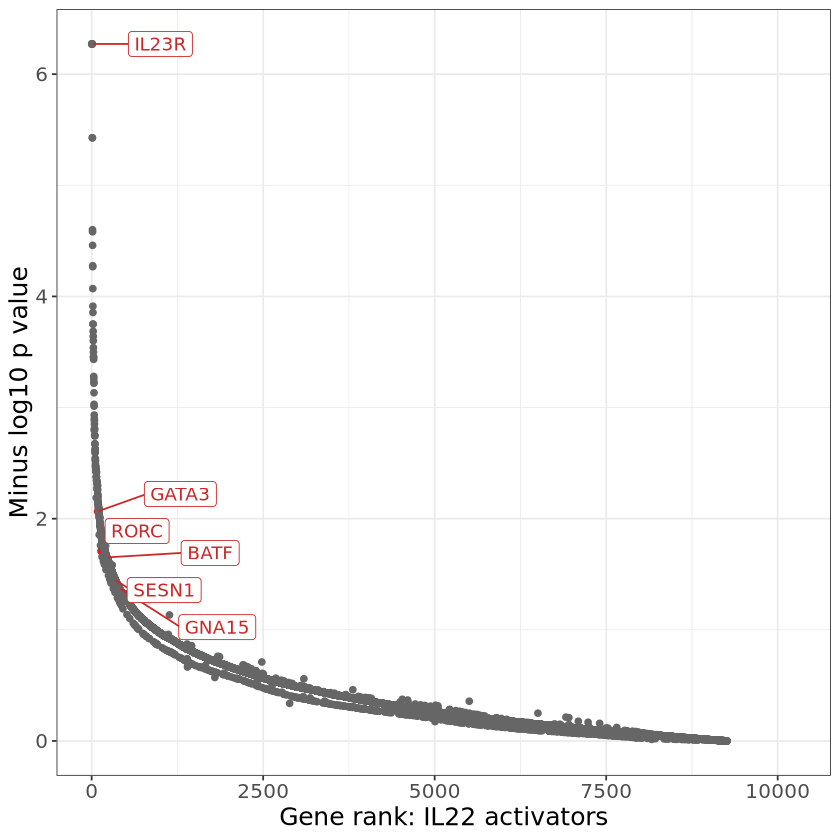

In [12]:
### Try just plotting the activators.
### And only plot the genes that were significant in the screen ( p < 0.05)
### IL22 activators
sg3_neg[, sigScreen_COGS := COGS_gene == T & `neg|p-value` < 0.05]
sg3_neg[sigScreen_COGS == T, Sig_Gene := id]
sg3_neg[sigScreen_COGS == T]

p <- ggplot(sg3_neg, aes(x = `neg|rank`, y = -log10(`neg|p-value`), label = Sig_Gene, color = sigScreen_COGS))
activators <- p + geom_point() + geom_label_repel(nudge_x = 1000, force_pull = 0, 
                                  max.overlaps = 1000) + 
theme_bw() + theme(legend.position="none") +
scale_color_manual(values=c("gray40", "firebrick3")) + 
labs(color = "multiCOGS gene significant in screen") + 
ylab("Minus log10 p value") + 
xlab("Gene rank: IL22 activators") + 
theme(text = element_text(size = 15))

print(activators)

Warning message:
“Removed 9220 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”
Warning message:
“Removed 9257 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


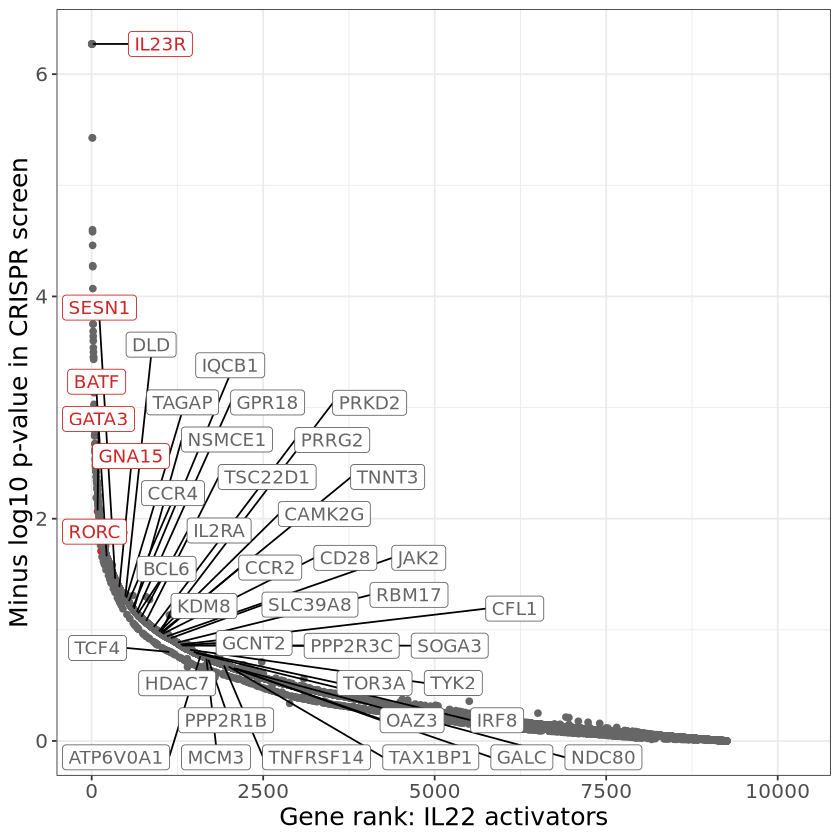

Warning message:
“Removed 9220 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”
Warning message:
“Removed 9257 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


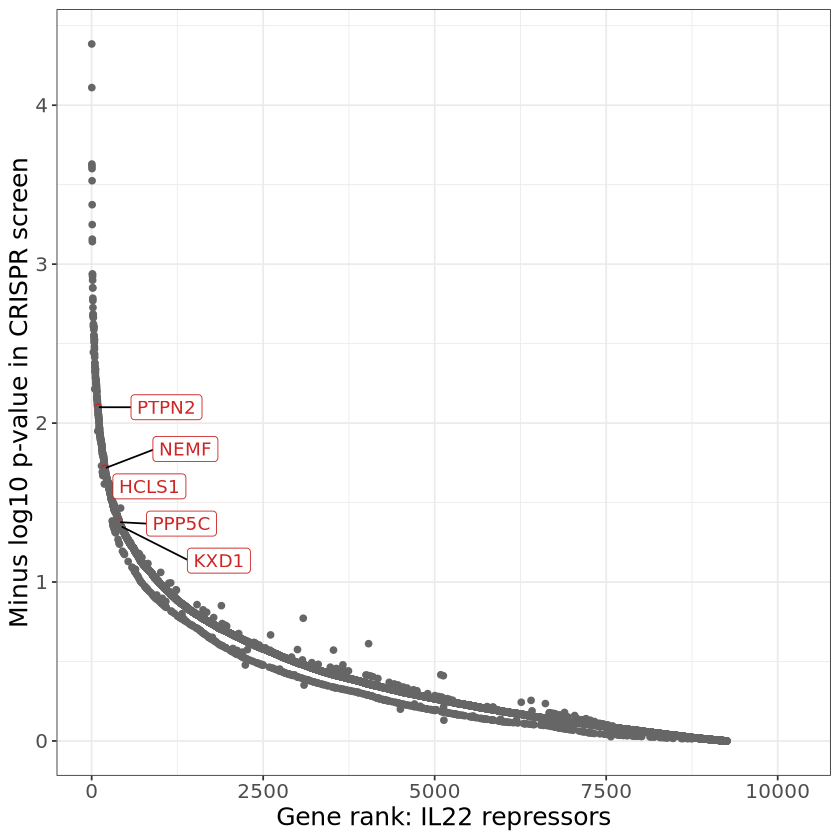

Warning message:
“Removed 9220 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”
Warning message:
“Removed 9257 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


pdf 
  2

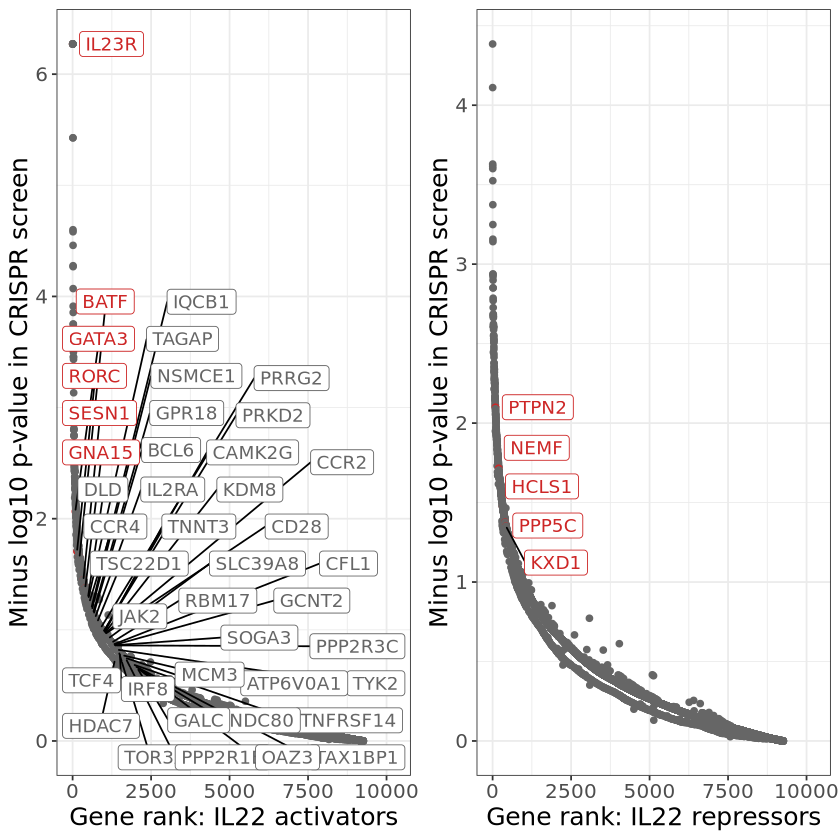

In [13]:
### Finally, plot with only COGS genes labelled that were in the leading edge for the significant enrichment in activators
### And in red, those that were significant in the screen (activators and repressors)

sg3 <- fread("~/HRJ_monocytes/hILCs/oltz_CRISPR/biorxiv_Brown2025_suppl/geneLevel_analyses_biorxiv_screen_uppercase.txt")

allTraits <- fread("~/HRJ_monocytes/hILCs/COGS_results/cross_trait/prioritised_genes_multiCOGS_table.txt")
allTraits_ILC3 <- allTraits[PSC_ILC3 == "+" | Celiac_ILC3 == "+" | IBD_ILC3 == "+" | UC_ILC3 == "+" | 
                           CD_ILC3 == "+" | Asthma_ILC3 == "+", .(`Gene Name`)]
#allTraits_ILC3

sg3[, COGS_gene := id %in% allTraits_ILC3$`Gene Name`]

### NEG - IL22 Activators
sg3_neg <- sg3[, c(1:8,16)]
setorder(sg3_neg, `neg|rank`)
# Set label for only the COGs genes in the leading edge (top 42 genes)
genes_to_label <- sg3_neg[COGS_gene == T, ][1:42, ]
#genes_to_label 
sg3_neg[id %in% genes_to_label$id, Gene := id]
#sg3_neg[, top_10percent := `neg|rank` <= (nrow(sg3)/10)] # this will be used for colouring.
sg3_neg[, sigScreen_COGS := COGS_gene == T & `neg|p-value` < 0.05]# this will now be used for colouring.


p <- ggplot(sg3_neg, aes(x = `neg|rank`, y = -log10(`neg|p-value`), label = Gene, color = sigScreen_COGS))
activators <- p + geom_point() + geom_label_repel(nudge_x = 1000, force_pull = 0, 
                                  max.overlaps = 1000, segment.color="black") + 
theme_bw() + theme(legend.position="none") +
scale_color_manual(values=c("gray40", "firebrick3")) + 
labs(color = "multiCOGS genes significant in CRISPR screen", label = "Leading edge multiCOGS genes") + 
ylab("Minus log10 p-value in CRISPR screen") + 
xlab("Gene rank: IL22 activators") + 
theme(text = element_text(size = 15)) 
#annotate(geom="text", x=7500, y=6.4, label="GSEA p-value = 0.0284",
#              color="red") # We will just describe the sinificance in the text
#length(unique(sg3_neg$id))
#nrow(sg3_neg)
#sg3_neg
activators

### POS - IL22 repressors - only label those that were p < 0.05, not the leading edge.
sg3_pos <- sg3[, c(1, 10:16)]
#sg3_pos
setorder(sg3_pos, `pos|rank`)
# Set label for only the COGs genes with p < 0.05
sg3_pos[COGS_gene == T & `pos|p-value` < 0.05, Gene := id]
sg3_pos[, sigScreen_COGS := COGS_gene == T & `pos|p-value` < 0.05]# this will now be used for colouring.
#sg3_pos[, top_10percent := `pos|rank` <= (nrow(sg3)/10)]

### IL22 repressors (i.e. pos ranking)
q <- ggplot(sg3_pos, aes(x = `pos|rank`, y = -log10(`pos|p-value`), label = Gene, color = sigScreen_COGS))
repressors <- q + geom_point() + geom_label_repel(nudge_x = 1000, force_pull = 0, 
                                  max.overlaps = 1000, segment.color="black") + 
theme_bw() + theme(legend.position="none") +
scale_color_manual(values=c("gray40", "firebrick3")) + 
labs(color = "multiCOGS genes significant in CRISPR screen") + 
ylab("Minus log10 p-value in CRISPR screen") + 
xlab("Gene rank: IL22 repressors") + 
theme(text = element_text(size = 15)) 
#annotate(geom="text", x=8000, y=4.5, label="GSEA p-value = 0.919 \n(not significant)",
#              color="red") # We will just describe the sinificance in the text
repressors

library(cowplot)
plot_grid(activators, repressors)
svg(file = "./CRISPRi_activators_repressors_COGS_screen3_V03.svg", width = 14, height = 5)
plot_grid(activators, repressors)
dev.off()

### Make a supplementary table.


In [16]:
setwd("~/HRJ_monocytes/hILCs/COGS_results/COGS_out")
sg3_COGS_intersect <- copy(sg3)

# BTW only 142 genes could be matched.
sg3_COGS_intersect[, 9 := NULL]
#sg3_COGS_intersect

cd <- fread("./Version3_revision2/revision_deLange_ILCs_hg38_SuSIE_combinedInteractions_extended_ABC023/Annotated_COGS_scores_data.table.txt")
cd_genes <- cd[cogs > 0.5]
IBD <- fread("./IBD_DeLange_28067908/IBD_DeLange_28067908_ILC3_SuSIE/Annotated_COGS_scores_data.table.txt")
ibd_genes <- IBD[cogs > 0.5]
cel <- fread("./CEL_Dubois_20190752/CEL_Dubois_20190752_ILC3_SuSIE/Annotated_COGS_scores_data.table.txt")
cel_genes <- cel[cogs > 0.5]
aao <- fread("./ASTAO_Ferreira_30929738/ASTAO_Ferreira_30929738_ILC3_SuSIE/Annotated_COGS_scores_data.table.txt")
aao_genes <- aao[cogs > 0.5]
psc <- fread("./PSC_Ji_27992413/PSC_Ji_27992413_ILC3_SuSIE/Annotated_COGS_scores_data.table.txt")
psc_genes <- psc[cogs > 0.5]
uc <- fread("./UC_DeLange_28067908/UC_DeLange_28067908_ILC3_SuSIE/Annotated_COGS_scores_data.table.txt")
uc_genes <- uc[cogs > 0.5]
sg3_COGS_intersect[, Asthma := id %in% aao_genes$gene]
sg3_COGS_intersect[, PSC := id %in% psc_genes$gene]
sg3_COGS_intersect[, Celiac := id %in% cel_genes$gene]
sg3_COGS_intersect[, CD := id %in% cd_genes$gene]
sg3_COGS_intersect[, IBD := id %in% ibd_genes$gene]
sg3_COGS_intersect[, UC := id %in% uc_genes$gene]

setnames(sg3_COGS_intersect, "COGS_gene", "multiCOGS gene in any trait")


setorder(sg3_COGS_intersect, -`multiCOGS gene in any trait`, `neg|score`)
#sg3_COGS_intersect

### Put + and - for each of the traits.
myTraits <- c("Asthma", "PSC", "Celiac", "CD", "IBD", "UC")
sg3_COGS_intersect[, (myTraits) := lapply(.SD, function(x) {
  fifelse(is.na(x), NA_character_, # preserve NA, and make sure column is character type
          fifelse(x == TRUE, "+", "-")) # fifelse is a fast version of ifelse, from data.table
}), .SDcols = myTraits]

print(head(sg3_COGS_intersect))
fwrite_headers(sg3_COGS_intersect, file = "../../oltz_CRISPR/biorxiv_Brown2025_suppl/COGS_vs_Brownetal.txt")

       id   num  neg|score neg|p-value  neg|fdr neg|rank neg|goodsgrna  neg|lfc
   <char> <int>      <num>       <num>    <num>    <int>         <int>    <num>
1:  IL23R     5 4.6000e-12  5.3500e-07 0.000550        2             5 -2.15250
2:  GATA3    10 1.2902e-03  8.6016e-03 0.744564       86             6 -0.82667
3:   RORC    10 3.3448e-03  1.9715e-02 0.918929      140             6 -0.55882
4:   BATF     5 5.4382e-03  2.2288e-02 0.918929      220             5 -0.95999
5:  SESN1     5 8.9571e-03  3.5508e-02 0.963759      344             3 -0.48111
6:  GNA15     5 1.0753e-02  4.2070e-02 0.968437      402             4 -1.78130
   pos|score pos|p-value  pos|fdr pos|rank pos|goodsgrna  pos|lfc
       <num>       <num>    <num>    <int>         <int>    <num>
1:   1.00000     1.00000 0.999999     9261             0 -2.15250
2:   0.10006     0.29205 0.993132     2175             3 -0.82667
3:   0.91935     0.96208 0.999999     8470             2 -0.55882
4:   0.99456     0.99461 0.999